<a href="https://colab.research.google.com/github/Leanhchudang2511/baitaptrituenhantao/blob/main/NhanDienKhuonMat_MTCNN_fixed_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 👤 Nhận Diện Khuôn Mặt — MTCNN + MobileNet
> Detect mặt trước → crop → nhận diện. Chuẩn hơn nhiều với ảnh ngoài đời thật.

In [1]:
# ── Cell 1: Mount Drive + Cài thư viện ────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# MTCNN: detect và crop khuôn mặt tự động
!pip install mtcnn -q
print('✅ Xong!')

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 73.8 MB/s eta 0:00:00
✅ Xong!


In [2]:
# ── Cell 2: Import ─────────────────────────────────────────────────────
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from mtcnn import MTCNN
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input  # ✅ FIX 3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from PIL import Image
import json

detector = MTCNN()
print(f'✅ TensorFlow: {tf.__version__}')
print('✅ MTCNN sẵn sàng!')


✅ TensorFlow: 2.20.0
✅ MTCNN sẵn sàng!


In [3]:
# ── Cell 3 FIX: Crop dataset — xử lý tên tiếng Việt có dấu ────────────
import os
import cv2
import numpy as np
from mtcnn import MTCNN
from PIL import Image
import unicodedata

detector = MTCNN()

SRC_DIR  = '/content/drive/MyDrive/Faceeee/BT tuần 7 AI'
CROP_DIR = '/content/drive/MyDrive/Faceeee/FACE_CROPPED'
IMG_SIZE = 224
MARGIN   = 20
MIN_FACE_SIZE = 30  # ✅ FIX: bỏ qua mặt quá nhỏ (tránh lỗi Conv2D)

skip_count = 0
crop_count = 0

def normalize_path(p):
    return unicodedata.normalize('NFC', p)

persons = []
with os.scandir(SRC_DIR) as it:
    for entry in it:
        if entry.is_dir():
            persons.append(entry.name)
persons = sorted(persons)

print(f'✅ Tìm thấy {len(persons)} người:')
for p in persons:
    print(f'  - {p}')

for person in persons:
    src_person = unicodedata.normalize('NFC', os.path.join(SRC_DIR, person))
    dst_person = unicodedata.normalize('NFC', os.path.join(CROP_DIR, person))
    os.makedirs(dst_person, exist_ok=True)

    imgs = []
    with os.scandir(src_person) as it:
        for entry in it:
            if entry.is_file() and entry.name.lower().endswith(('.jpg', '.jpeg', '.png')):
                imgs.append(entry.name)

    person_crop = 0
    person_skip = 0

    for fname in imgs:
        src_path = os.path.join(src_person, fname)
        dst_path = os.path.join(dst_person, fname)

        if os.path.exists(dst_path):
            person_crop += 1
            continue

        try:
            img_bgr = cv2.imread(src_path)
            if img_bgr is None:
                raise ValueError('Không đọc được ảnh')

            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            try:
                faces = detector.detect_faces(img_rgb)
            except Exception:
                # ✅ FIX: ảnh quá nhỏ khiến MTCNN Conv2D bị lỗi → fallback luôn
                faces = []

            # ✅ FIX: lọc mặt quá nhỏ trước khi crop
            valid_faces = [
                f for f in faces
                if f['box'][2] >= MIN_FACE_SIZE and f['box'][3] >= MIN_FACE_SIZE
            ]

            if not valid_faces:
                # Fallback: resize thẳng ảnh gốc
                resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
                Image.fromarray(resized).save(dst_path)
                person_skip += 1
            else:
                # Lấy mặt confidence cao nhất
                face = max(valid_faces, key=lambda f: f['confidence'])
                x, y, w, h = face['box']
                x1 = max(0, x - MARGIN)
                y1 = max(0, y - MARGIN)
                x2 = min(img_rgb.shape[1], x + w + MARGIN)
                y2 = min(img_rgb.shape[0], y + h + MARGIN)
                cropped = img_rgb[y1:y2, x1:x2]

                # ✅ FIX: kiểm tra vùng crop đủ lớn trước khi resize
                if cropped.shape[0] < MIN_FACE_SIZE or cropped.shape[1] < MIN_FACE_SIZE:
                    resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
                else:
                    resized = cv2.resize(cropped, (IMG_SIZE, IMG_SIZE))

                Image.fromarray(resized).save(dst_path)
                person_crop += 1

        except Exception as e:
            print(f'    ⚠️  Lỗi {fname}: {e}')
            person_skip += 1
            continue

    crop_count  += person_crop
    skip_count  += person_skip
    print(f'  ✅ {person}: {person_crop} crop, {person_skip} fallback')

print(f'\n🎉 Crop xong!')
print(f'  Crop được mặt : {crop_count} ảnh')
print(f'  Fallback       : {skip_count} ảnh')
print(f'  Dataset mới    : {CROP_DIR}')


✅ Tìm thấy 26 người:
  - Bùi Khôi Nguyên
  - Bùi Thành Luân
  - Chu Đặng Lê Anh
  - Hồ Công Minh Quân
  - Hồ Thị Thanh Vy
  - Hồ Văn Quý
  - Huỳnh Châu Gia Phú
  - Lê Nguyễn Quỳnh Như
  - Nguyễn Gia Kiên
  - Nguyễn Hoài An
  - Nguyễn Ngọc Bảo Uyên
  - Nguyễn Phương Mai
  - Nguyễn Quốc Anh
  - Nguyễn Đức Duy
  - Nguyễn Đức Minh
  - Phan Bá Phú Sĩ
  - Phạm Kim Đạt
  - Trần Hiếu Thiện
  - Trần Hoài Trọng
  - Trần Hồ Đức Bảo
  - Trương Gia Kỳ
  - Vũ Minh Khương
  - trần trí khang
  - Đỗ Nguyên Anh
  - Đỗ Phan Thành Đạt
  - Đỗ Trần Nam Mỹ
  ✅ Bùi Khôi Nguyên: 59 crop, 0 fallback
  ✅ Bùi Thành Luân: 60 crop, 0 fallback
  ✅ Chu Đặng Lê Anh: 60 crop, 0 fallback
  ✅ Hồ Công Minh Quân: 60 crop, 0 fallback
  ✅ Hồ Thị Thanh Vy: 60 crop, 0 fallback
  ✅ Hồ Văn Quý: 60 crop, 0 fallback
  ✅ Huỳnh Châu Gia Phú: 60 crop, 0 fallback
  ✅ Lê Nguyễn Quỳnh Như: 59 crop, 0 fallback
  ✅

In [4]:
import os
FACE_CROPPED = '/content/drive/MyDrive/Faceeee/FACE_CROPPED'
for person in sorted(os.listdir(FACE_CROPPED)):
    count = len(os.listdir(os.path.join(FACE_CROPPED, person)))
    print(f'{person}: {count} ảnh')

Bùi Khôi Nguyên: 59 ảnh
Bùi Thành Luân: 60 ảnh
Chu Đặng Lê Anh: 60 ảnh
Hồ Công Minh Quân: 60 ảnh
Hồ Thị Thanh Vy: 60 ảnh
Hồ Văn Quý: 60 ảnh
Huỳnh Châu Gia Phú: 60 ảnh
Lê Nguyễn Quỳnh Như: 59 ảnh
Nguyễn Gia Kiên: 60 ảnh
Nguyễn Hoài An: 60 ảnh
Nguyễn Ngọc Bảo Uyên: 61 ảnh
Nguyễn Phương Mai: 64 ảnh
Nguyễn Quốc Anh: 60 ảnh
Nguyễn Quốc Anh (1): 60 ảnh
Nguyễn Đức Duy: 60 ảnh
Nguyễn Đức Minh: 60 ảnh
Phan Bá Phú Sĩ: 61 ảnh
Phạm Kim Đạt: 60 ảnh
Trần Hiếu Thiện: 72 ảnh
Trần Hoài Trọng: 60 ảnh
Trần Hồ Đức Bảo: 76 ảnh
Trương Gia Kỳ: 87 ảnh
Vũ Minh Khương: 60 ảnh
Vũ Minh Khương (1): 60 ảnh
trần trí khang: 92 ảnh
Đỗ Nguyên Anh: 41 ảnh
Đỗ Nguyên Anh (1): 41 ảnh
Đỗ Phan Thành Đạt: 94 ảnh
Đỗ Trần Nam Mỹ: 0 ảnh
Đỗ Trần Nam Mỹ (1): 0 ảnh


In [5]:
import os

base = '/content/drive/MyDrive/Faceeee'
for item in sorted(os.scandir(base), key=lambda e: e.name):
    print(f'{"📁" if item.is_dir() else "📄"} {item.name}')
    if item.is_dir():
        subs = list(os.scandir(item.path))
        print(f'   └── {len(subs)} items')

📁 BT tuần 7 AI
   └── 26 items
📁 FACE_CROPPED
   └── 30 items
📄 face_class_names.json
📄 face_model_best.h5
📄 face_training_result.png


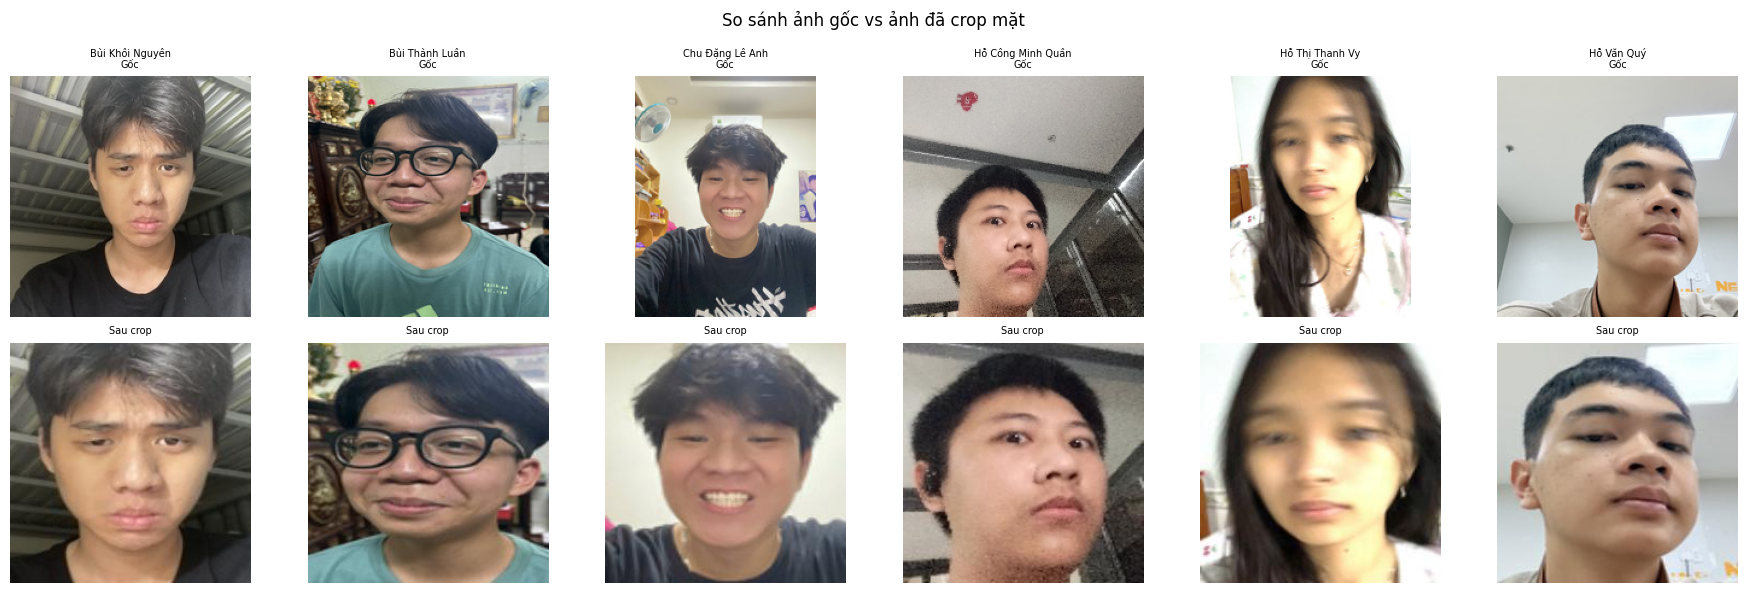

In [6]:
# ── Cell 4: Xem thử ảnh gốc vs ảnh đã crop ────────────────────────────
import random

persons = sorted(os.listdir(CROP_DIR))[:6]
fig, axes = plt.subplots(2, 6, figsize=(18, 6))

for col, person in enumerate(persons):
    src_imgs = os.listdir(os.path.join(SRC_DIR, person))
    fname = random.choice(src_imgs)

    # Gốc
    img_orig = Image.open(os.path.join(SRC_DIR, person, fname))
    axes[0, col].imshow(img_orig)
    axes[0, col].set_title(f'{person}\nGốc', fontsize=7)
    axes[0, col].axis('off')

    # Đã crop
    crop_path = os.path.join(CROP_DIR, person, fname)
    if os.path.exists(crop_path):
        img_crop = Image.open(crop_path)
        axes[1, col].imshow(img_crop)
        axes[1, col].set_title('Sau crop', fontsize=7)
    axes[1, col].axis('off')

plt.suptitle('So sánh ảnh gốc vs ảnh đã crop mặt', fontsize=12)
plt.tight_layout()
plt.show()

In [7]:
# ── Cell 5: Data generator ─────────────────────────────────────────────
# ✅ FIX 3: Dùng preprocess_input thay rescale=1./255
# MobileNetV2 chuẩn cần scale về [-1, 1], không phải [0, 1]
TRAIN_DIR  = CROP_DIR
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # ✅ FIX 3
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.6, 1.4],
    channel_shift_range=20,
    fill_mode='nearest',
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # ✅ FIX 3
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(224, 224), batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(224, 224), batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', shuffle=False
)

num_classes = train_gen.num_classes
class_names = {v: k for k, v in train_gen.class_indices.items()}

print(f'✅ Số người  : {num_classes}')
print(f'✅ Train     : {train_gen.samples} ảnh')
print(f'✅ Validation: {val_gen.samples} ảnh')


Found 1419 images belonging to 30 classes.
Found 348 images belonging to 30 classes.
✅ Số người  : 30
✅ Train     : 1419 ảnh
✅ Validation: 348 ảnh


In [8]:
# ── Cell 6: Build model MobileNetV2 ───────────────────────────────────
tf.keras.backend.clear_session()

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('✅ Model sẵn sàng!')
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Model sẵn sàng!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 30)             │         3,870 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,622,686 (10.00 MB)

 Trainable params: 364,702 (1.39 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
# ── Cell 7: Phase 1 — Train classifier ────────────────────────────────
SAVE_PATH = '/content/drive/MyDrive/Faceeee/face_model_best.h5'

print('='*50)
print('PHASE 1: Train classifier (base model đóng băng)')
print('='*50)

history1 = model.fit(
    train_gen, epochs=15, validation_data=val_gen,
    callbacks=[
        EarlyStopping(monitor='val_accuracy', patience=5,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint(SAVE_PATH, monitor='val_accuracy',
                        save_best_only=True, verbose=1),
    ]
)
print(f'\n✅ Phase 1 xong! Best: {max(history1.history["val_accuracy"]):.4f}')

PHASE 1: Train classifier (base model đóng băng)
Epoch 1/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.0887 - loss: 3.4716
Epoch 1: val_accuracy improved from None to 0.51149, saving model to /content/drive/MyDrive/Faceeee/face_model_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Faceeee/face_model_best.h5
45/45 ━━━━━━━━━━━━━━━━━━━━ 515s 11s/step - accuracy: 0.1395 - loss: 3.1784 - val_accuracy: 0.5115 - val_loss: 2.3847
Epoch 2/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3290 - loss: 2.4531
Epoch 2: val_accuracy improved from 0.51149 to 0.72701, saving model to /content/drive/MyDrive/Faceeee/face_model_best.h5



Epoch 2: finished saving model to /content/drive/MyDrive/Faceeee/face_model_best.h5
45/45 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.3749 - loss: 2.2406 - val_accuracy: 0.7270 - val_loss: 1.2815
Epoch 3/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5204 - loss: 1.6931
Epoch 3: val_accuracy improved from 0.72701 to 0.80172, saving model to /content/drive/MyDrive/Faceeee/face_model_best.h5



Epoch 3: finished saving model to /content/drive/MyDrive/Faceeee/face_model_best.h5
45/45 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.5518 - loss: 1.5682 - val_accuracy: 0.8017 - val_loss: 0.7726
Epoch 4/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6090 - loss: 1.3288
Epoch 4: val_accuracy improved from 0.80172 to 0.82759, saving model to /content/drive/MyDrive/Faceeee/face_model_best.h5



Epoch 4: finished saving model to /content/drive/MyDrive/Faceeee/face_model_best.h5
45/45 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.6413 - loss: 1.2251 - val_accuracy: 0.8276 - val_loss: 0.5467
Epoch 5/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6998 - loss: 1.0395
Epoch 5: val_accuracy improved from 0.82759 to 0.84770, saving model to /content/drive/MyDrive/Faceeee/face_model_best.h5


...


Epoch 6: finished saving model to /content/drive/MyDrive/Faceeee/face_model_best.h5
45/45 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.7188 - loss: 0.8232 - val_accuracy: 0.8563 - val_loss: 0.3534
Epoch 7/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7753 - loss: 0.6884
Epoch 7: val_accuracy improved from 0.85632 to 0.86494, saving model to /content/drive/MyDrive/Faceeee/face_model_best.h5



Epoch 7: finished saving model to /content/drive/MyDrive/Faceeee/face_model_best.h5
45/45 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.7808 - loss: 0.6771 - val_accuracy: 0.8649 - val_loss: 0.3417
Epoch 8/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7579 - loss: 0.7554
Epoch 8: val_accuracy did not improve from 0.86494
45/45 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.7815 - loss: 0.6786 - val_accuracy: 0.8649 - val_loss: 0.3031
Epoch 9/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7727 - loss: 0.6040
Epoch 9: val_accuracy improved from 0.86494 to 0.87069, saving model to /content/drive/MyDrive/Faceeee/face_model_best.h5



Epoch 9: finished saving model to /content/drive/MyDrive/Faceeee/face_model_best.h5
45/45 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.7773 - loss: 0.6051 - val_accuracy: 0.8707 - val_loss: 0.2925
Epoch 10/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7916 - loss: 0.5634
Epoch 10: val_accuracy improved from 0.87069 to 0.87356, saving model to /content/drive/MyDrive/Faceeee/face_model_best.h5



Epoch 10: finished saving model to /content/drive/MyDrive/Faceeee/face_model_best.h5
45/45 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.8006 - loss: 0.5497 - val_accuracy: 0.8736 - val_loss: 0.2501
Epoch 11/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8158 - loss: 0.4937
Epoch 11: val_accuracy improved from 0.87356 to 0.87931, saving model to /content/drive/MyDrive/Faceeee/face_model_best.h5



Epoch 11: finished saving model to /content/drive/MyDrive/Faceeee/face_model_best.h5
45/45 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.8161 - loss: 0.4976 - val_accuracy: 0.8793 - val_loss: 0.2663
Epoch 12/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8337 - loss: 0.4727
Epoch 12: val_accuracy did not improve from 0.87931
45/45 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.8259 - loss: 0.4725 - val_accuracy: 0.8793 - val_loss: 0.2653
Epoch 13/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8294 - loss: 0.4380
Epoch 13: val_accuracy did not improve from 0.87931
45/45 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.8372 - loss: 0.4187 - val_accuracy: 0.8764 - val_loss: 0.2503
Epoch 14/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8220 - loss: 0.4708
Epoch 14: val_accuracy did not improve from 0.87931
45/45 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.8217 - loss: 0.4692 - val_accuracy: 0.8793 - val_loss: 0.2540
Epoch 15/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/s

In [10]:
# ── Cell 8: Phase 2 — Fine-tune ────────────────────────────────────────
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('='*50)
print('PHASE 2: Fine-tune (mở 30 layer cuối)')
print('='*50)

history2 = model.fit(
    train_gen, epochs=30, validation_data=val_gen,
    callbacks=[
        EarlyStopping(monitor='val_accuracy', patience=8,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint(SAVE_PATH, monitor='val_accuracy',
                        save_best_only=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=1e-7, verbose=1)
    ]
)
print(f'\n🏆 Best val_accuracy: {max(history2.history["val_accuracy"]):.4f}')

PHASE 2: Fine-tune (mở 30 layer cuối)
Epoch 1/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3650 - loss: 2.1932
Epoch 1: val_accuracy improved from None to 0.87644, saving model to /content/drive/MyDrive/Faceeee/face_model_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Faceeee/face_model_best.h5
45/45 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.4087 - loss: 2.0308 - val_accuracy: 0.8764 - val_loss: 0.2710 - learning_rate: 1.0000e-05
Epoch 2/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5118 - loss: 1.5796
Epoch 2: val_accuracy did not improve from 0.87644
45/45 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.5342 - loss: 1.5005 - val_accuracy: 0.8707 - val_loss: 0.2799 - learning_rate: 1.0000e-05
Epoch 3/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5855 - loss: 1.2768
Epoch 3: val_accuracy did not improve from 0.87644
45/45 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.6110 - loss: 1.1957 - val_accuracy: 0.8678 - val_loss: 0.2913 - learning_rate: 1.0000e-05
Epoch 4/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6795 - loss: 1.0145
Epoch 4: val_accuracy did not improve from 0.87644

Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
45/45 ━

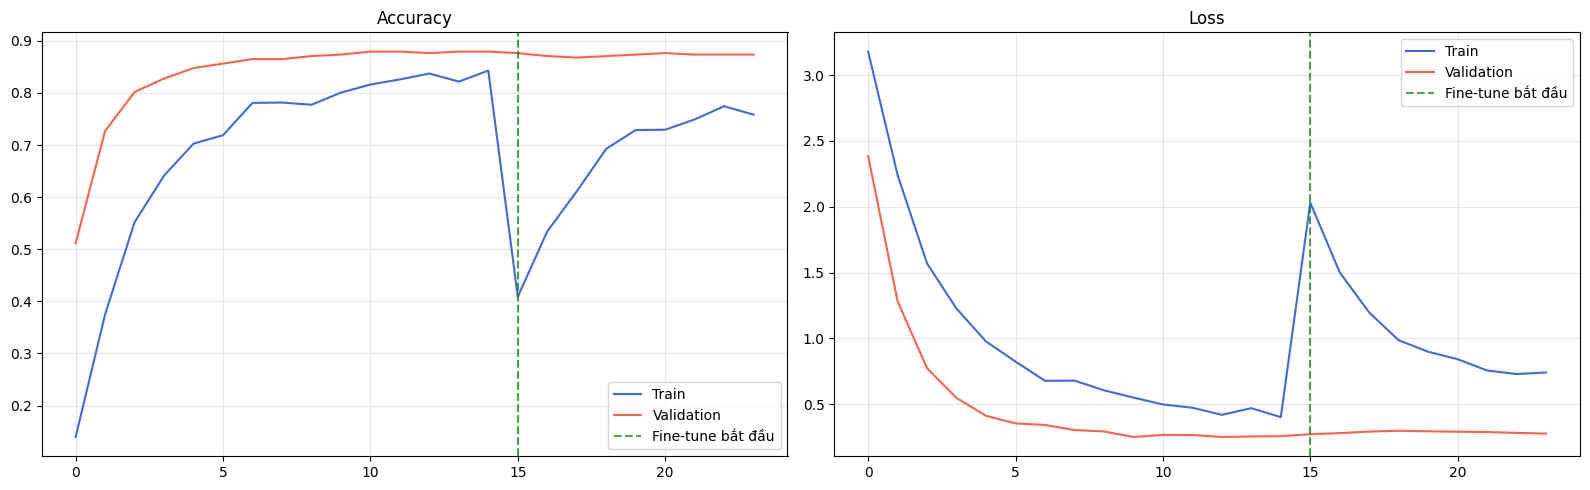

In [11]:
# ── Cell 9: Vẽ biểu đồ ────────────────────────────────────────────────
acc     = history1.history['accuracy']     + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss    = history1.history['loss']         + history2.history['loss']
val_loss= history1.history['val_loss']     + history2.history['val_loss']
p1_end  = len(history1.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
for ax, tr, vl, title in [(ax1, acc, val_acc, 'Accuracy'), (ax2, loss, val_loss, 'Loss')]:
    ax.plot(tr, label='Train', color='royalblue')
    ax.plot(vl, label='Validation', color='tomato')
    ax.axvline(p1_end, color='green', linestyle='--', alpha=0.7, label='Fine-tune bắt đầu')
    ax.set_title(title); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Faceeee/face_training_result.png', dpi=150)
plt.show()

In [12]:
# ── Cell 10: Lưu model + class names ──────────────────────────────────
with open('/content/drive/MyDrive/Faceeee/face_class_names.json', 'w', encoding='utf-8') as f:
    json.dump(train_gen.class_indices, f, ensure_ascii=False, indent=2)

print('✅ Đã lưu:')
print('  📦 face_model_best.h5')
print('  📋 face_class_names.json')

✅ Đã lưu:
  📦 face_model_best.h5
  📋 face_class_names.json


Upload ảnh chụp ngoài đời thật...


Saving z7843920233137_111394935c060c895ca98fddad83beda.jpg to z7843920233137_111394935c060c895ca98fddad83beda.jpg

🖼️  z7843920233137_111394935c060c895ca98fddad83beda.jpg
🔍 Phát hiện 1 khuôn mặt

Mặt #1 (detect confidence: 1.00)
  ✅ Chu Đặng Lê Anh (89.9%)
     - Chu Đặng Lê Anh: 89.9%
     - Vũ Minh Khương (1): 2.7%
     - Vũ Minh Khương: 2.6%



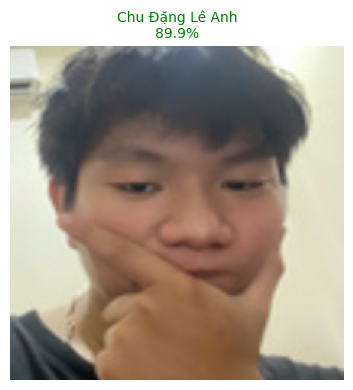

In [14]:
# ── Cell 11: Predict ảnh ngoài đời thật ───────────────────────────────
# Pipeline chuẩn: Upload → MTCNN detect mặt → crop → resize → predict

from google.colab import files
from tensorflow.keras.models import load_model

# ✅ FIX 2: Define MARGIN ở đây, không phụ thuộc Cell 3
MARGIN    = 20
THRESHOLD = 0.55   # confidence thấp hơn ngưỡng → báo không nhận ra

model = load_model('/content/drive/MyDrive/Faceeee/face_model_best.h5')
with open('/content/drive/MyDrive/Faceeee/face_class_names.json', 'r', encoding='utf-8') as f:
    class_indices = json.load(f)

# ✅ FIX 1: ép int(v) vì JSON serialize key thành string, nhưng top3 trả int
class_names_map = {int(v): k for k, v in class_indices.items()}


def predict_from_path(img_path, show=True):
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        print(f'⚠️  Không đọc được file: {img_path}')
        return
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    faces = detector.detect_faces(img_rgb)

    if not faces:
        print('⚠️  Không detect được khuôn mặt trong ảnh!')
        return

    print(f'🔍 Phát hiện {len(faces)} khuôn mặt\n')

    fig, axes = plt.subplots(1, len(faces), figsize=(4 * len(faces), 4))
    if len(faces) == 1:
        axes = [axes]

    for i, face in enumerate(faces):
        x, y, w, h = face['box']
        conf_det = face['confidence']

        # Crop mặt (có margin)
        x1 = max(0, x - MARGIN)
        y1 = max(0, y - MARGIN)
        x2 = min(img_rgb.shape[1], x + w + MARGIN)
        y2 = min(img_rgb.shape[0], y + h + MARGIN)
        cropped = img_rgb[y1:y2, x1:x2]
        face_img = cv2.resize(cropped, (224, 224))

        # ✅ FIX 3: dùng preprocess_input (scale [-1,1]) khớp với lúc train
        x_input = np.expand_dims(preprocess_input(face_img.astype(np.float32)), axis=0)
        preds = model.predict(x_input, verbose=0)[0]
        top3  = np.argsort(preds)[::-1][:3]
        best_conf = preds[top3[0]]
        best_name = class_names_map[top3[0]]  # ✅ FIX 1: int key khớp

        print(f'Mặt #{i+1} (detect confidence: {conf_det:.2f})')
        if best_conf < THRESHOLD:
            print(f'  ⚠️  Không nhận ra (confidence: {best_conf*100:.1f}%)')
        else:
            print(f'  ✅ {best_name} ({best_conf*100:.1f}%)')
        for idx in top3:
            print(f'     - {class_names_map[idx]}: {preds[idx]*100:.1f}%')
        print()

        color = 'green' if best_conf >= THRESHOLD else 'red'
        title = f'{best_name}\n{best_conf*100:.1f}%' if best_conf >= THRESHOLD \
                else f'Không rõ\n{best_conf*100:.1f}%'
        axes[i].imshow(face_img)
        axes[i].set_title(title, color=color, fontsize=10)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()


# ── Upload và test ─────────────────────────────────────────────────────
print('Upload ảnh chụp ngoài đời thật...')
uploaded = files.upload()

for filename in uploaded.keys():
    img_path = f'/content/{filename}'
    print('\n' + '='*40)
    print(f'🖼️  {filename}')
    print('='*40)
    predict_from_path(img_path)
